In [ ]:
import warnings
from pathlib import Path
from IPython.display import display
import os


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/final assignment data/household_power_consumption.txt',sep=';',
                 na_values = ['?','nan'],parse_dates={'dt':['Date','Time']}, index_col='dt',low_memory=False,infer_datetime_format=True,dayfirst=True)
print(df.shape)
df.head(10)

(2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
2006-12-16 17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
2006-12-16 17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
2006-12-16 17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0


In [ ]:
print(df.isna().sum().to_frame(name='Missing Values'))

                       Missing Values
Global_active_power             25979
Global_reactive_power           25979
Voltage                         25979
Global_intensity                25979
Sub_metering_1                  25979
Sub_metering_2                  25979
Sub_metering_3                  25979


In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


print('Resampling data to hourly frequency...')
df_resampled = df.select_dtypes(include=np.number).resample('H').mean()

df_resampled['hour'] = df_resampled.index.hour
df_resampled['day_of_week'] = df_resampled.index.dayofweek
df_resampled['month'] = df_resampled.index.month
df_resampled['day_of_month'] = df_resampled.index.day


target_col = 'Global_reactive_power'

df_resampled.dropna(inplace=True)

print(df_resampled.shape)
df_resampled.head(10)

Resampling data to hourly frequency...
(34168, 11)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,day_of_month
dt,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,16
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,16
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,16
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,16
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,16
2006-12-16 22:00:00,2.200133,0.056167,238.760000,9.523333,0.0,0.133333,4.433333,22,5,12,16
2006-12-16 23:00:00,2.061600,0.071433,240.619667,8.896667,0.0,0.083333,0.000000,23,5,12,16
2006-12-17 00:00:00,1.882467,0.102433,240.961833,8.126667,0.0,0.466667,0.000000,0,6,12,17
2006-12-17 01:00:00,3.349400,0.136933,240.448333,14.246667,0.0,25.233333,0.000000,1,6,12,17


       Global_reactive_power
count           34168.000000
mean                0.123727
std                 0.066851
min                 0.000000
25%                 0.078000
50%                 0.106917
75%                 0.149433
max                 0.774333


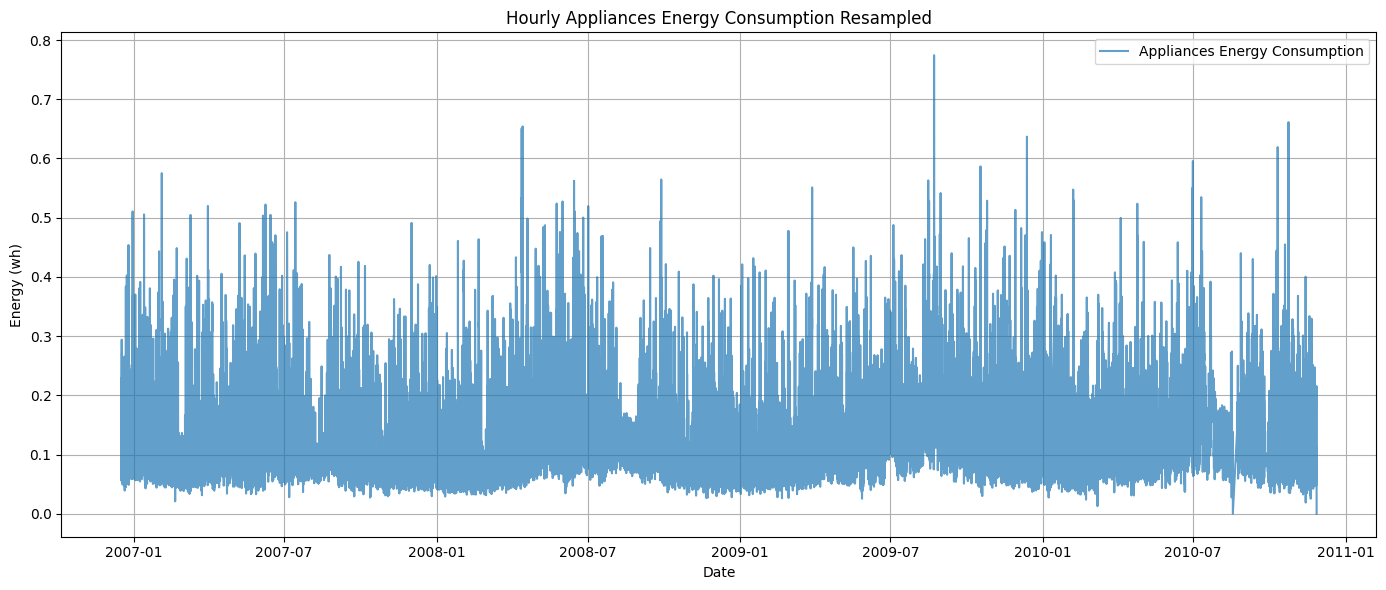

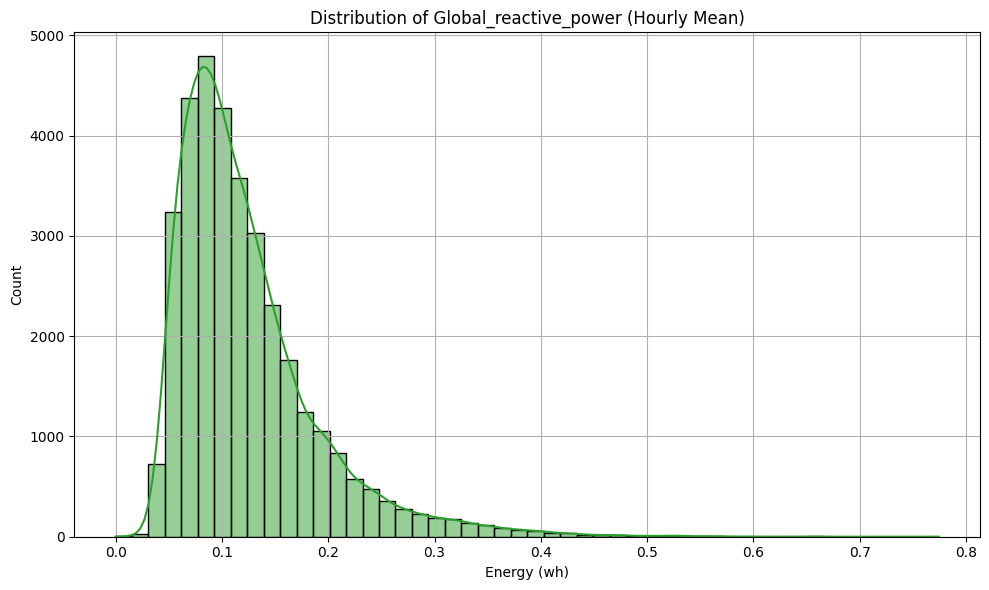

In [ ]:
print(df_resampled[[target_col]].describe())

plt.figure(figsize=(14,6))
plt.plot(df_resampled.index, df_resampled[target_col], label='Appliances Energy Consumption', color = 'tab:blue', alpha = 0.7)
plt.title('Hourly Appliances Energy Consumption Resampled')
plt.xlabel('Date')
plt.ylabel('Energy (wh)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df_resampled[target_col], kde=True, bins=50, color='tab:green')
plt.title(f'Distribution of {target_col} (Hourly Mean)')
plt.xlabel('Energy (wh)')
plt.tight_layout()
plt.show()

In [ ]:
feature_cols = [col for col in df_resampled.columns if col != target_col]
X = df_resampled[feature_cols]
y = df_resampled[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (27334, 10)
X_test shape: (6834, 10)


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100,random_state=42)
}

results = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    mse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[model_name] = {'MAE': mae, 'R2': r2, 'MSE': mse}


                        MAE        R2       MSE
Linear Regression  0.037781  0.317699  0.053558
Random Forest      0.031707  0.462317  0.047544
Gradient Boosting  0.030659  0.490697  0.046272


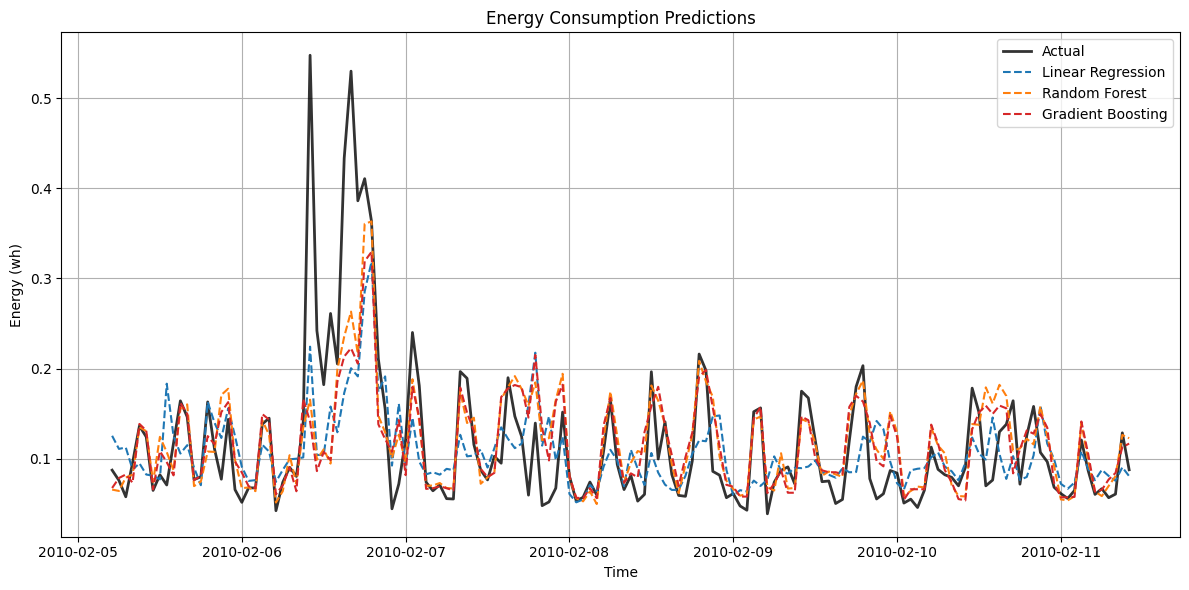

Best Model: Gradient Boosting
With R2: 0.4907


In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)

slice_n = 150
plt.figure(figsize=(12,6))
plt.plot(y_test.index[:slice_n], y_test.iloc[:slice_n], label='Actual', color='black', linewidth=2, alpha=0.8)

colors = ['tab:blue', 'tab:orange', 'tab:red']
for i, (model_name,pred) in enumerate(predictions.items()):
    plt.plot(y_test.index[:slice_n], pred[:slice_n], label=f'{model_name}', linestyle='--', color=colors[i])

plt.title('Energy Consumption Predictions')
plt.xlabel('Time')
plt.ylabel('Energy (wh)')
plt.legend()
plt.tight_layout()
plt.show()

best_model_name = results_df['MSE'].idxmin()
print(f'Best Model: {best_model_name}')
print(f'With R2: {results_df.loc[best_model_name, "R2"]:.4f}')

In [ ]:
display(results_df)

,MAE,R2,MSE
Linear Regression,0.037781,0.317699,0.053558
Random Forest,0.031707,0.462317,0.047544
Gradient Boosting,0.030659,0.490697,0.046272
